<a href="https://colab.research.google.com/github/hruivnewuin/Faith_INFO4670_Spring2026-/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [6]:
x = data[['Age', 'Salary']]
y = data['Purchased']

print('X shape:', x.shape)
print('y distribution:\n', y.value_counts())

X shape: (400, 2)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [88]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.15, random_state=2, stratify=y
)
print('Train size:', x_train.shape[0], 'Test size:', x_test.shape[0])

Train size: 340 Test size: 60


### Step 4: Feature Scaling

In [89]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print('Scaling complete')

Scaling complete


### Step 5: Train Logistic Regression Model

In [86]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
print('Model trained')

Model trained


### Step 6: Predict and Evaluate

In [90]:
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.8833333333333333

Confusion Matrix:
 [[38  1]
 [ 6 15]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.97      0.92        39
           1       0.94      0.71      0.81        21

    accuracy                           0.88        60
   macro avg       0.90      0.84      0.86        60
weighted avg       0.89      0.88      0.88        60



### Step 7: Visualization of Decision Regions

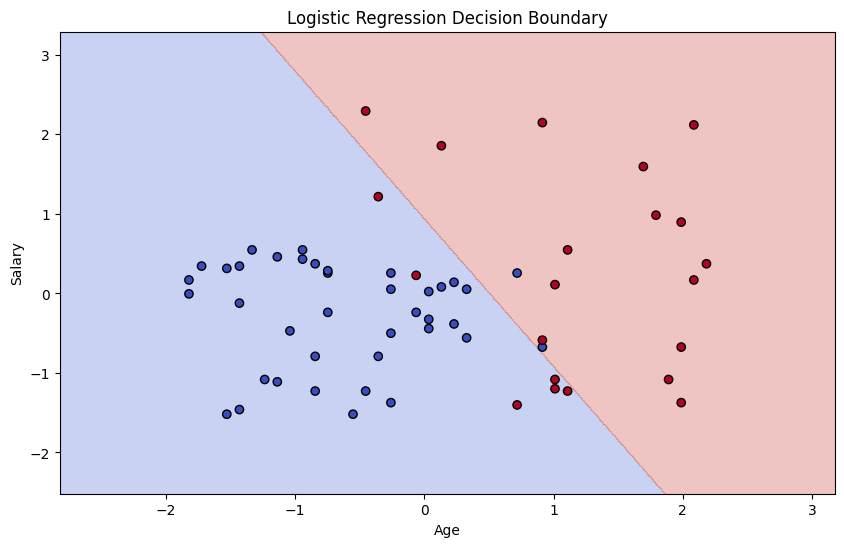

In [91]:
import numpy as np
import matplotlib.pyplot as plt

x_set, y_set = x_test[:, :2], y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(x_train[:, :2], y_train)

x1_min, x1_max = x_set[:, 0].min() - 1, x_set[:, 0].max() + 1
x2_min, x2_max = x_set[:, 1].min() - 1, x_set[:, 1].max() + 1
x1, x2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)
Z = model_2d.predict(np.array([x1.ravel(), x2.ravel()]).T)
Z = Z.reshape(x1.shape)

plt.figure(figsize=(10, 6))
plt.contourf(x1, x2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(x_set[:, 0], x_set[:, 1], c=y_set, edgecolors='k', cmap='coolwarm')
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()


## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here


Logistical regression can be used for classification because it applies a threshold to convert possibilities into discrete class predictions. Based on the model, customers who are older and have higher salaries are more likey to purchase a car. Customers with more disposable income and life staility are batter positioned to make major purchases. The class imbalance could cause bias and data quality issues like potential outliers or noise in salary/age data. Additional features I would consider is family status. I would also add outlier removal and check feature selection for which features contribute most to predictions.

